# NEPSE Volatility Analysis - Starter Notebook

This notebook loads the scraped NEPSE index data and computes:

1. Log returns
2. Rolling historical volatility (15-day)
3. GARCH(1,1) model-implied volatility
4. Visualization of all estimates


## 1. Load Libraries and Data

The notebook expects the CSV file to be in the same folder:

`nepse_index_2015-01-01_to_2026-06-03.csv`


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model

plt.style.use("seaborn-v0_8-whitegrid")

DATA_FILE = Path("nepse_index_2015-01-01_to_2026-06-03.csv")
OUTPUT_CSV = Path("nepse_volatility_analysis.csv")
OUTPUT_PNG = Path("nepse_volatility_analysis.png")

df = pd.read_csv(DATA_FILE, parse_dates=["date_ad"])
df = df.sort_values("date_ad").set_index("date_ad")

print(f"Loaded {len(df):,} NEPSE observations")
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
df.head()


Loaded 2,596 NEPSE observations
Date range: 2015-01-01 to 2026-06-03


,index_value,absolute_change,percentage_change
date_ad,,,
2015-01-01,903.68,1.35,0.15
2015-01-04,917.50,13.82,1.53
2015-01-05,919.77,2.27,0.25
2015-01-06,917.41,-2.36,-0.26
2015-01-07,924.54,7.13,0.78


## 2. Compute Log Returns

Log returns are calculated as:

`log_return_t = ln(index_value_t / index_value_{t-1})`

They are useful because they are time-additive and commonly used in volatility modeling.


In [2]:
df["log_return"] = np.log(df["index_value"] / df["index_value"].shift(1))
df["log_return_pct"] = df["log_return"] * 100

df[["index_value", "log_return", "log_return_pct"]].head(10)


,index_value,log_return,log_return_pct
date_ad,,,
2015-01-01,903.68,NaN,NaN
2015-01-04,917.50,0.015177,1.517726
2015-01-05,919.77,0.002471,0.247106
2015-01-06,917.41,-0.002569,-0.256916
2015-01-07,924.54,0.007742,0.774183
2015-01-08,930.97,0.006931,0.693074
2015-01-11,928.33,-0.002840,-0.283978
2015-01-12,927.80,-0.000571,-0.057108
2015-01-13,937.48,0.010379,1.037923


## 3. Rolling Historical Volatility (15-Day)

This uses the rolling standard deviation of daily log returns over a 15-trading-day window.

The annualized estimate uses `sqrt(252)`, a common trading-day convention.


In [3]:
ROLLING_WINDOW = 15
ANNUALIZATION_DAYS = 252

df["rolling_vol_15d_daily_pct"] = (
    df["log_return"].rolling(ROLLING_WINDOW).std() * 100
)
df["rolling_vol_15d_annualized_pct"] = (
    df["rolling_vol_15d_daily_pct"] * np.sqrt(ANNUALIZATION_DAYS)
)

df[["log_return_pct", "rolling_vol_15d_daily_pct", "rolling_vol_15d_annualized_pct"]].dropna().head()


,log_return_pct,rolling_vol_15d_daily_pct,rolling_vol_15d_annualized_pct
date_ad,,,
2015-01-26,-0.043351,1.020719,16.203409
2015-01-27,0.669835,0.980818,15.570006
2015-01-28,1.317250,1.006991,15.985488
2015-01-29,-0.142804,1.001462,15.897719
2015-02-01,0.483293,0.998277,15.847150


## 4. Fit GARCH(1,1)

GARCH(1,1) models volatility clustering by allowing conditional variance to depend on:

- a constant term,
- the prior period shock,
- the prior period variance.

The model is fit on percentage log returns.


In [4]:
returns_pct = df["log_return_pct"].dropna()

garch_model = arch_model(
    returns_pct,
    mean="Constant",
    vol="GARCH",
    p=1,
    q=1,
    dist="normal",
    rescale=False,
)

garch_result = garch_model.fit(disp="off")
print(garch_result.summary())

df.loc[returns_pct.index, "garch_vol_daily_pct"] = garch_result.conditional_volatility
df["garch_vol_annualized_pct"] = df["garch_vol_daily_pct"] * np.sqrt(ANNUALIZATION_DAYS)


                     Constant Mean - GARCH Model Results                      
Dep. Variable:         log_return_pct   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -4135.70
Distribution:                  Normal   AIC:                           8279.40
Method:            Maximum Likelihood   BIC:                           8302.84
                                        No. Observations:                 2595
Date:                Thu, Jun 04 2026   Df Residuals:                     2594
Time:                        17:49:20   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0489  2.384e-02      2.050  4.039e-02 [2.

## 5. Save Processed Data

This creates a clean analysis CSV containing the original NEPSE index plus all computed return and volatility columns.


In [5]:
analysis_columns = [
    "index_value",
    "absolute_change",
    "percentage_change",
    "log_return",
    "log_return_pct",
    "rolling_vol_15d_daily_pct",
    "rolling_vol_15d_annualized_pct",
    "garch_vol_daily_pct",
    "garch_vol_annualized_pct",
]

df[analysis_columns].to_csv(OUTPUT_CSV)
print(f"Saved processed volatility data to: {OUTPUT_CSV.resolve()}")
df[analysis_columns].tail()


Saved processed volatility data to: /Users/anamgiri/Desktop/Nepal stock market/nepse_volatility_analysis.csv


,index_value,absolute_change,percentage_change,log_return,log_return_pct,rolling_vol_15d_daily_pct,rolling_vol_15d_annualized_pct,garch_vol_daily_pct,garch_vol_annualized_pct
date_ad,,,,,,,,,
2026-05-26,2777.10,-9.24,-0.33,-0.003325,-0.332528,0.744898,11.824894,0.935525,14.851001
2026-05-27,2782.10,4.99,0.17,0.001799,0.179882,0.742490,11.786660,0.895727,14.219223
2026-06-01,2755.37,-26.72,-0.96,-0.009654,-0.965430,0.797565,12.660955,0.850301,13.498118
2026-06-02,2777.58,22.21,0.80,0.008028,0.802831,0.782470,12.421327,0.922999,14.652159
2026-06-03,2780.25,2.66,0.09,0.000961,0.096081,0.694867,11.030677,0.929377,14.753404


## 6. Visualize NEPSE Returns and Volatility

The final panel compares the 15-day rolling historical volatility with the GARCH(1,1) model-implied volatility.


Saved chart to: /Users/anamgiri/Desktop/Nepal stock market/nepse_volatility_analysis.png


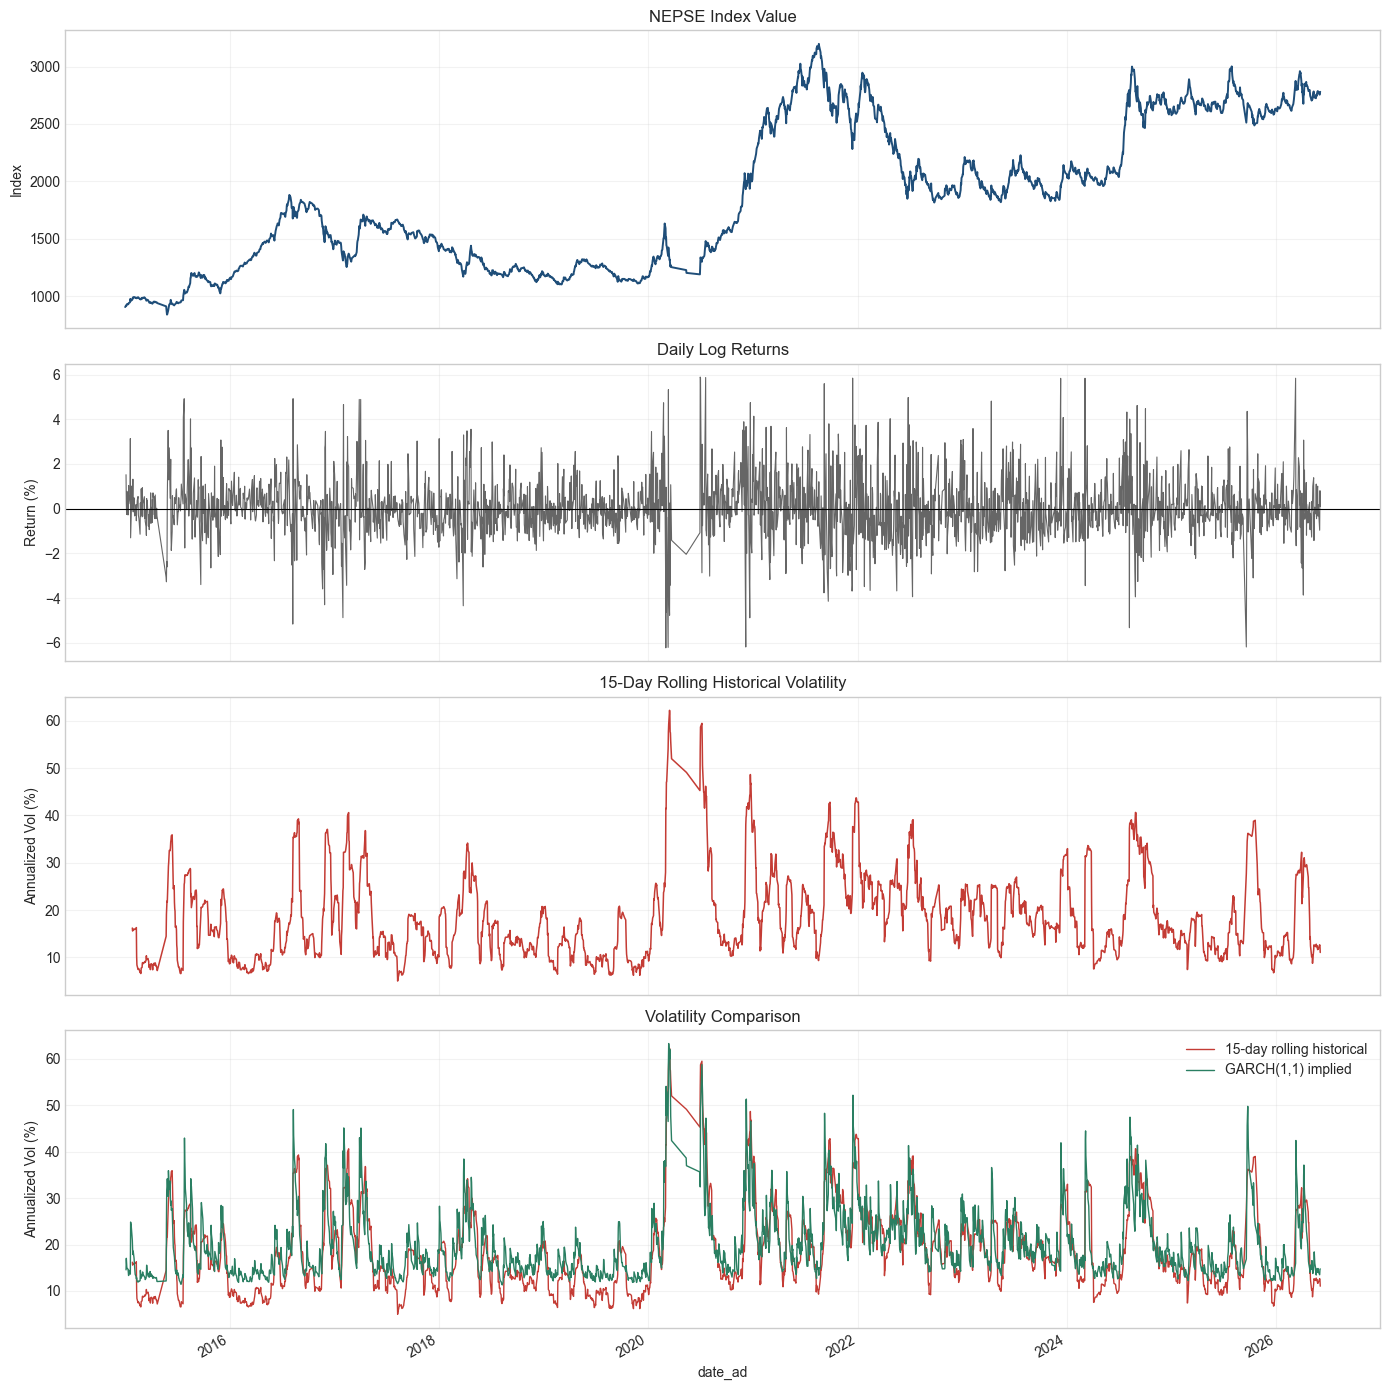

In [6]:
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

df["index_value"].plot(ax=axes[0], color="#1f4e79", linewidth=1.4)
axes[0].set_title("NEPSE Index Value")
axes[0].set_ylabel("Index")

df["log_return_pct"].plot(ax=axes[1], color="#666666", linewidth=0.8)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Daily Log Returns")
axes[1].set_ylabel("Return (%)")

df["rolling_vol_15d_annualized_pct"].plot(ax=axes[2], color="#c43c35", linewidth=1.1)
axes[2].set_title("15-Day Rolling Historical Volatility")
axes[2].set_ylabel("Annualized Vol (%)")

df["rolling_vol_15d_annualized_pct"].plot(
    ax=axes[3], label="15-day rolling historical", color="#c43c35", linewidth=1.0
)
df["garch_vol_annualized_pct"].plot(
    ax=axes[3], label="GARCH(1,1) implied", color="#2a7f62", linewidth=1.0
)
axes[3].set_title("Volatility Comparison")
axes[3].set_ylabel("Annualized Vol (%)")
axes[3].legend()

for ax in axes:
    ax.grid(True, alpha=0.25)

fig.tight_layout()
fig.savefig(OUTPUT_PNG, dpi=180, bbox_inches="tight")
print(f"Saved chart to: {OUTPUT_PNG.resolve()}")
plt.show()


## 7. Quick Summary Statistics


In [7]:
summary = df[
    [
        "log_return_pct",
        "rolling_vol_15d_annualized_pct",
        "garch_vol_annualized_pct",
    ]
].describe()

summary


,log_return_pct,rolling_vol_15d_annualized_pct,garch_vol_annualized_pct
count,2595.000000,2581.000000,2595.000000
mean,0.043307,18.555826,19.992264
std,1.315896,8.915201,7.405189
min,-6.226214,4.985969,11.309631
25%,-0.647765,11.839164,14.591135
50%,-0.039629,16.572387,17.758846
75%,0.649648,23.429122,23.138519
max,5.884603,62.243556,63.283859
